In [194]:
import math
import numpy as np

## Calculating repudiation and forgery possibilities

In [1]:
import numpy as np
from scipy.stats import binom
import math
from helpers.utils import writecsv

In [10]:
def repudiation_prob_P1(bM, bH, bH_prime):
    left_term = (2 * bH + bM)/math.pow(2, bH_prime - 1)
    right_term = (3 * bH)/math.pow(2, bH_prime - 1)

    return max(left_term, right_term)

def forgery_prob_P1(bM, bH):
    return bM/(math.pow(2, bH - 1))


    

In [35]:
import math

def find_optimal_params(func, bM, total_budget=1e-10,      # even n, per protocol structure
                          bH_range=None):             # emax <= n/2

    best = None  # (lP, n, bH, emax, b_prime_H)
    if bH_range is None:
        bH_range=range(int(np.log2(bM) + 1), 128)

    for bH in bH_range:
        # quick necessary check before looping emax: p = bM * 2^(1-bH) <= 1
        p = bM * 2**(1 - bH)
        if p > 1:
            continue  # bH too small at this bM, skip entirely

        eps_for = forgery_prob_P1(bM, bH) 
        remaining = total_budget - eps_for
        if remaining <= 0:
            continue

        #comb_term = compute_combinatorial_term(n, emax)
        #if comb_term > remaining:
        #    continue
        numerator = max(2 * bH + bM, 3 * bH)

        # solve b'_H analytically, then round UP (ceil) since b'_H must be an integer
        # and rounding down could violate the security bound
        raw_b_prime_H = math.log2(numerator/ remaining) + 1
        b_prime_H = math.ceil(raw_b_prime_H)

        # verify the rounded integer value actually satisfies the bound
        eps_rep = numerator / (2**(b_prime_H - 1))
        #eps_rep = max(comb_term, eps_prime)
        total = eps_for + eps_rep

        if total > total_budget:
            continue  # shouldn't happen given ceil, but guard anyway

        l = func(bH, b_prime_H)

        if best is None or l < best[0]:
            best = (l,  bH, b_prime_H, total, eps_for, eps_rep)

    return best

In [28]:
def l_total(bH, b_prime_H):
    return 6 * bH + 5 * b_prime_H

def l_AliceBob(bH, b_prime_H):
    return 3*bH 

def l_BobCharlie(bH, b_prime_H):
    return 5*b_prime_H


In [32]:
find_optimal_params(l_total, bM=80000)

(571, 51, 53, 8.884049051971488e-11)

In [38]:
func = l_BobCharlie
path = f"log/params_l_BobCharlie.csv" #bM,l_total,n,bH,emax,b_prime_H,total_error

for bM_test in np.arange(80, 800, 80): # 80 to 80_000_000_000
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(800, 8_000, 800): 
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(8_000, 80_000, 8_000): 
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(80_000_000_000, 800_000, 80_000): 
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(800_000, 8_000_000, 800_000): 
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(8_000_000, 80_000_000, 8_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(80_000_000, 800_000_000, 80_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(800_000_000, 8_000_000_000, 800_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

for bM_test in np.arange(8_000_000_000, 80_000_000_000, 8_000_000_000): # 80 to 80_000_000_000
    res = find_optimal_params(func, bM=bM_test)
    writecsv(path, [bM_test, res[0], res[1], res[2], res[3], res[4], res[5]], False)

res = find_optimal_params(func, bM=80_000_000_000)
writecsv(path, [80_000_000_000, res[0], res[1], res[2], res[3], res[4], res[5]], False)

In [55]:
def get_optimal_params(bM):
    with open("log/params_l_total.csv", "r") as f:
        data = csv.DictReader(f)
        for row in data:
            if int(row['bM']) == bM:
                params = [int(row['bH']), int(row['b_prime_H'])]
                return params

    l,  bH, b_prime_H, total, eps_for, eps_rep = find_optimal_params(l_total, bM)
    params = [bH, b_prime_H]
    return params

In [57]:
bM_vals = [80, 800, 8_000, 80_000, 800_000, 8_000_000]
for bM in bM_vals:
    print(bM, get_optimal_params(bM))

80 [41, 44]
800 [45, 45]
8000 [48, 49]
80000 [51, 53]
800000 [55, 55]
8000000 [58, 59]


In [58]:
bM_vals = [80_000_000, 800_000_000]
for bM in bM_vals:
    print(bM, get_optimal_params(bM))

80000000 [61, 63]
800000000 [65, 65]


### Plotting Graphs

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import csv
import numpy as np

from scipy.optimize import curve_fit

def log_graph(x, a, b): # function for curve-fitting the following graph data points
    return a * np.log(x) + b

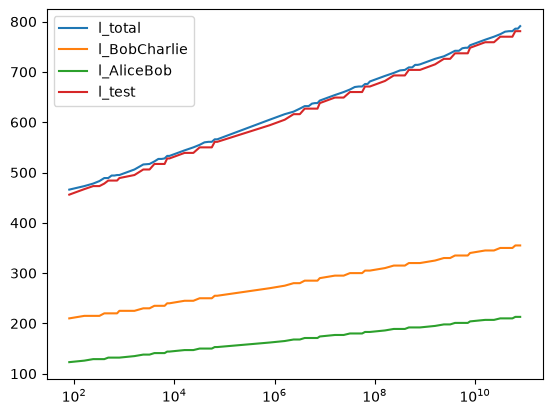

In [42]:
fig, ax = plt.subplots()



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['l_total']))
ax.plot(x1, y1, label=f'l_total')

#l_BobCharlie
x2 = []
y2 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['l_BobCharlie']))
ax.plot(x2, y2, label=f'l_BobCharlie')

#l_AliceBob
x3 = []
y3 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['l_AliceBob']))
ax.plot(x3, y3, label=f'l_AliceBob')

#test = l_BobCharlie + l_AliceBob + l_AliceCharlie = l_BobCharlie + 2 * l_AliceBob 
y4 = [y2[i] + y3[i]*2 for i in range(len(x3))]
ax.plot(x3, y4, label=f'l_test')

ax.set_xscale('log', base=10)
ax.legend()

[ 1.44284117 35.08317139] [[ 2.89810070e-05 -4.47376870e-04]
 [-4.47376870e-04  8.07219165e-03]]
a = 1.4428 ± 0.0054
b = 35.0832 ± 0.0898
[ 1.44546541 34.67279825] [[ 2.89020246e-05 -4.46157628e-04]
 [-4.46157628e-04  8.05019241e-03]]
a = 1.4455 ± 0.0054
b = 34.6728 ± 0.0897
[ 1.42997299 37.26811755] [[ 0.00087428 -0.0134962 ]
 [-0.0134962   0.24351711]]
a = 1.4300 ± 0.0296
b = 37.2681 ± 0.4935


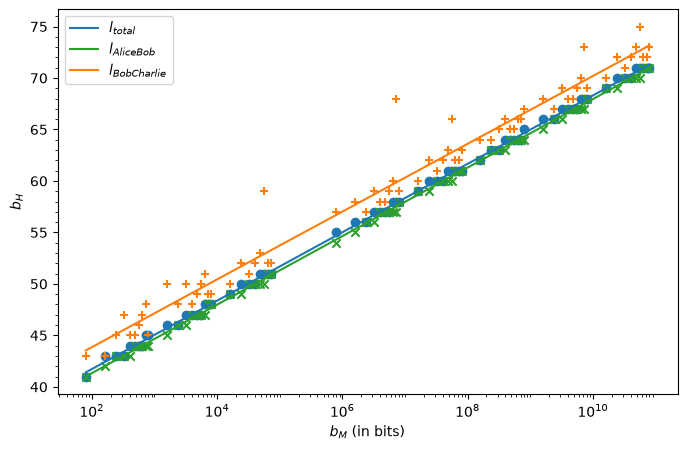

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['bH']))
ax.scatter(x1, y1, marker="o", color='tab:blue') #, linestyle=(0, (5, 5)))

#l_AliceBob
x2 = []
y2 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['bH']))
ax.scatter(x2, y2, marker="x", color='tab:green') # linestyle="dotted")

#l_BobCharlie
x3 = []
y3 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['bH']))
ax.scatter(x3, y3, marker="+", color='tab:orange') #,linestyle="dotted")




# curve-fit: l_total
popt, pcov = curve_fit(log_graph, x1, y1)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x1:
    y_test.append(log_graph(x, a, b))
ax.plot(x1, y_test, label='$l_{total}$', color='tab:blue')


# curve-fit: l_AliceBob
popt, pcov = curve_fit(log_graph, x2, y2)
print(popt, pcov)

a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x2:
    y_test.append(log_graph(x, a, b))
ax.plot(x2, y_test, label='$l_{AliceBob}$', color='tab:green')

# curve-fit: l_BobCharlie
popt, pcov = curve_fit(log_graph, x3, y3)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x3:
    y_test.append(log_graph(x, a, b))
ax.plot(x3, y_test, label='$l_{BobCharlie}$', color='tab:orange')

ax.set_xscale('log', base=10)

## set x ticks
ax.minorticks_on()
x_major = ticker.LogLocator(base = 10.0, numticks = 5)
ax.xaxis.set_major_locator(x_major)
x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylabel('$b_H$')
ax.set_xlabel('$b_M$ (in bits)')

ax.legend()


[ 15.82038856 391.22062114] [[ 0.00090391 -0.01395358]
 [-0.01395358  0.25176984]]
a = 15.8204 ± 0.0301
b = 391.2206 ± 0.5018
[  4.33639624 104.01839476] [[ 0.00026012 -0.00401542]
 [-0.00401542  0.07245173]]
a = 4.3364 ± 0.0161
b = 104.0184 ± 0.2692
[  7.15989222 174.67894873] [[ 0.00094773 -0.01463001]
 [-0.01463001  0.26397493]]
a = 7.1599 ± 0.0308
b = 174.6789 ± 0.5138


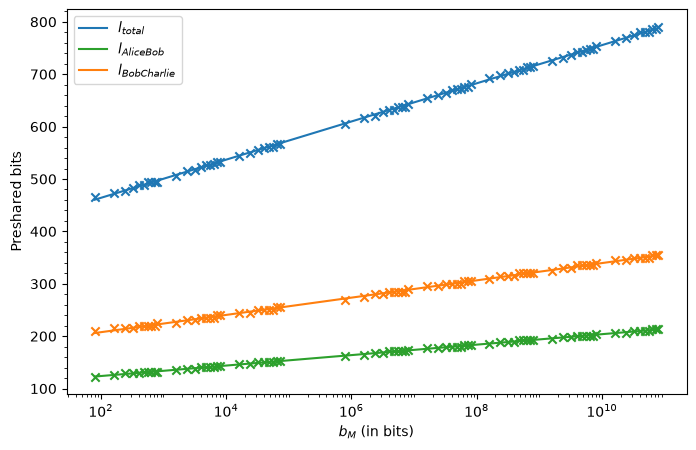

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))



# l_total
x1 = []
y1 = []
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(float(row['l_total']))
ax.scatter(x1, y1, marker="x", color="tab:blue") #, linestyle='dotted')


#l_BobCharlie
x3 = []
y3 = []
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(float(row['l_BobCharlie']))
ax.scatter(x3, y3, marker="x", color="tab:orange") #, linestyle='dotted')

#l_AliceBob
x2 = []
y2 = []
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(float(row['l_AliceBob']))
ax.scatter(x2, y2, marker="x", color="tab:green") #, linestyle='dotted')








# curve-fit: l_total
popt, pcov = curve_fit(log_graph, x1, y1)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x1:
    y_test.append(log_graph(x, a, b))
ax.plot(x1, y_test, label='$l_{total}$', color='tab:blue')


# curve-fit: l_AliceBob
popt, pcov = curve_fit(log_graph, x2, y2)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x2:
    y_test.append(log_graph(x, a, b))
ax.plot(x2, y_test, label='$l_{AliceBob}$', color='tab:green')

# curve-fit: l_BobCharlie
popt, pcov = curve_fit(log_graph, x3, y3)
print(popt, pcov)
a, b = popt

sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

a, b = popt
y_test = []
for x in x3:
    y_test.append(log_graph(x, a, b))
ax.plot(x3, y_test, label='$l_{BobCharlie}$', color='tab:orange')



ax.set_xscale('log', base=10)

## set x ticks
ax.minorticks_on()
x_major = ticker.LogLocator(base = 10.0, numticks = 5)
ax.xaxis.set_major_locator(x_major)
x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylabel('Preshared bits')
ax.set_xlabel('$b_M$ (in bits)')

ax.legend()

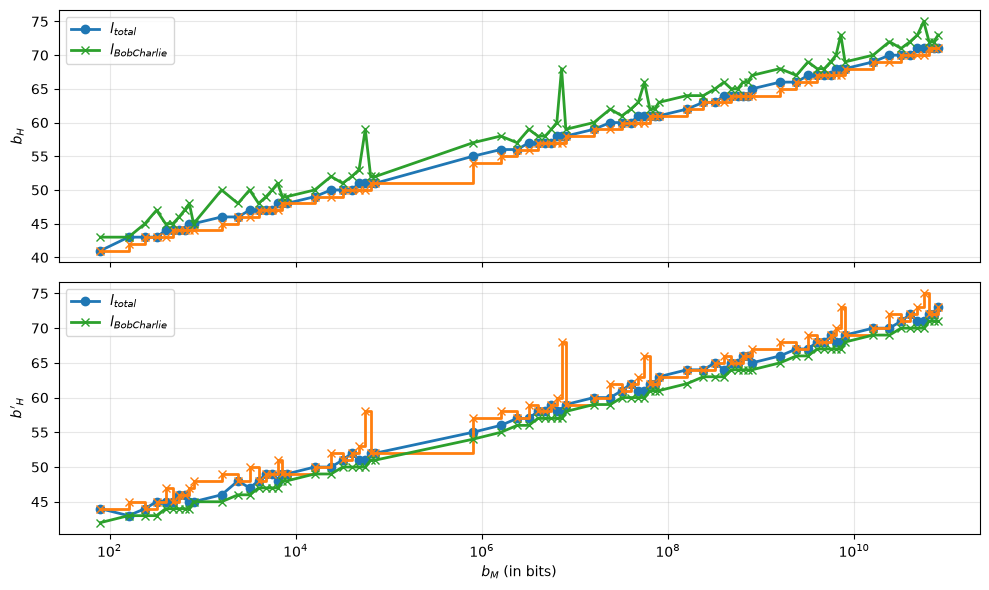

In [57]:
import matplotlib.pyplot as plt
bM_values = []
results1 = {'bH':[], 'b_prime_H':[]}
with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        bM_values.append(int(row['bM']))
        results1['bH'].append(int(row['bH']))
        results1['b_prime_H'].append(int(row['b_prime_H']))

results2 = {'bH':[], 'b_prime_H':[]}
with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        results2['bH'].append(int(row['bH']))
        results2['b_prime_H'].append(int(row['b_prime_H']))

results3 = {'bH':[], 'b_prime_H':[]}
with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        results3['bH'].append(int(row['bH']))
        results3['b_prime_H'].append(int(row['b_prime_H']))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

params = ['bH', 'b_prime_H']  # adjust to the actual variable names
for ax, param in zip(axes, params):
    ax.plot(bM_values, results1[param], marker='o', linewidth=2, label='$l_{total}$')
    ax.step(bM_values, results2[param], where='post', marker='x', linewidth=2)
    ax.plot(bM_values, results3[param], marker='x', linewidth=2, label='$l_{BobCharlie}$')
    if param == 'bH':
        label = '$b_H$'
    elif param == 'emax':
        label = '$e_{max}$'
    elif param == 'b_prime_H':
        label = "$b'_{H}$"
    else:
        label = param

    ax.set_ylabel(label)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('$b_M$ (in bits)')
plt.tight_layout()


In [51]:
x1 =[]
y1 = []
z1 = []

x2 = []
y2 = []
z2 = []

x3 = []
y3 = []
z3 = []

with open("log/params_l_total.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x1.append(int(row['bM']))
        y1.append(int(row['bH']))
        z1.append(int(row['b_prime_H']))

with open("log/params_l_AliceBob.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x2.append(int(row['bM']))
        y2.append(int(row['bH']))
        z2.append(int(row['b_prime_H']))

with open("log/params_l_BobCharlie.csv", "r") as f:
    data = csv.DictReader(f)
    for row in data:
        x3.append(int(row['bM']))
        y3.append(int(row['bH']))
        z3.append(int(row['b_prime_H']))

print(x1 == x2)
print(x1 == x3)

print(y1 == y2)
print(y1 == y3)

print(z1 == z2)
print(z1 == z3)

for i in range(len(x1)):
    if y1[i] != y2[i]:
        print(x1[i], y1[i], y2[i])

True
True
False
False
False
False
160 43 42
400 44 43
720 45 44
800 45 44
1600 46 45
3200 47 46
6400 48 47
24000 50 49
48000 51 50
56000 51 50
800000 55 54
1600000 56 55
3200000 57 56
6400000 58 57
7200000 58 57
24000000 60 59
48000000 61 60
56000000 61 60
400000000 64 63
800000000 65 64
1600000000 66 65
3200000000 67 66
6400000000 68 67
7200000000 68 67
24000000000 70 69
48000000000 71 70
56000000000 71 70


In [8]:
import csv
import numpy as np

In [1]:
bM_vals = [80, 800, 8_000, 80_000, 800_000, 8_000_000]
def get_timelog(bM, param, name):
    l = []
    with open(f"log/timelog_{name}.csv", "r") as f:
        data = csv.DictReader(f)
        for row in data:
            if int(row['bM']) == bM:
                l.append(row[param])
    return l
        

In [6]:
bM = 8000000
name = 'Alice'
print(get_timelog(bM, 'bH', name), get_timelog(bM, 'b_prime_H', name))

['58', '58', '58', '58', '58'] ['59', '59', '59', '59', '59']


In [27]:
bM = 80000000
name = 'Alice'
#timestamp,id,bM,bH,b_prime_H,forg_prob,rep_prob,t_total,t_QKD_Bob,t_QKD_Charlie,t_signatures_total,t_single_signature,mode

a = [get_timelog(bM, 't_total', name), get_timelog(bM, 't_QKD_Bob', name),get_timelog(bM, 't_QKD_Charlie', name), get_timelog(bM, 't_signatures_total', name), get_timelog(bM, 't_single_signature', name)]
#print(a)
for res in a:
    new = [float(t) for t in res]
    mean = sum(new)/5
    std_dev = np.sqrt(sum([(x - mean)**2 for x in new])/(5-1))
    #print(mean, std_dev, end=' & ')
    print(f"${mean} {std_dev}$ ", end=' & ')
#print(res)

$902.1617388749961 248.5481640200372$  & $1.9910533166024833 0.10068878738061537$  & $2.161415900173597 0.30647020565497685$  & $350.90368425841444 83.75594694710445$  & $350.83756437518167 83.74326707957614$  & 

In [42]:
bM = 80_000_000
name = 'Charlie'
a = [get_timelog(bM, 't_total', name), get_timelog(bM, 't_QKD', name), get_timelog(bM, 't_verifications_total', name), get_timelog(bM, 't_single_verification', name)]
#print(a)
for res in a:
    new = [float(t) for t in res]
    mean = sum(new)/5
    std_dev = np.sqrt(sum([(x - mean)**2 for x in new])/(5-1))
    print(f"${mean} {std_dev}$ ", end=' & ')
#print(res)

$904.8536278581712 249.8550382224505$  & $1.6007162918103859 0.33550190020914067$  & $543.394076524768 168.883588371438$  & $543.3798463168089 168.8760483272742$  & 

In [43]:
bM = 80_000_000
name = 'Bob'
a = [get_timelog(bM, 't_total', name), get_timelog(bM, 't_QKD', name), get_timelog(bM, 't_verifications_total', name), get_timelog(bM, 't_single_verification', name)]
#print(a)
for res in a:
    new = [float(t) for t in res]
    mean = sum(new)/5
    std_dev = np.sqrt(sum([(x - mean)**2 for x in new])/(5-1))
    print(f"${mean} {std_dev}$ ", end=' & ')
#print(res)

$904.2311585997929 249.56593014879977$  & $1.4512409331742675 0.10401474434510602$  & $546.7270344332326 172.0607382111654$  & $546.5208842416062 172.0422017925052$  & 